<a href="https://colab.research.google.com/github/paolaCaushi/anomalyDetection/blob/provaMeMaps/plotMapProdTheft.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from geopy.distance import distance
from sklearn.cluster import KMeans
import folium

# Load the Excel file
file_path = 'resultatiQueryDistancaKudo.xlsx'
data = pd.read_excel(file_path)

# Extract latitude and longitude columns
geo_data = data[['Latitudine', 'Longitudine']].dropna()

# Function to calculate geographical distance
def calculate_distance(p1, p2):
    return distance(p1, p2).meters  # Convert distance to meters

# Custom distance function for K-Means clustering
def custom_distance(X, Y):
    n_samples_X, n_samples_Y = X.shape[0], Y.shape[0]
    D = np.empty((n_samples_X, n_samples_Y))
    for i in range(n_samples_X):
        for j in range(n_samples_Y):
            D[i, j] = calculate_distance(X[i], Y[j])
    return D

# Number of clusters
num_clusters = 5

# Apply K-Means clustering with custom distance metric
kmeans = KMeans(n_clusters=num_clusters, init='k-means++', max_iter=300, n_init=10, random_state=0)
kmeans.fit(geo_data)

# Add cluster labels to original data
geo_data['cluster'] = kmeans.labels_

# Convert cluster labels to integers
geo_data['cluster'] = geo_data['cluster'].astype(int)

# Create a map centered at the average location
m = folium.Map(location=[geo_data['Latitudine'].mean(), geo_data['Longitudine'].mean()], zoom_start=10)

# Define cluster colors
cluster_colors = ['red', 'blue', 'green', 'purple', 'orange']

# Add points to the map
for _, row in geo_data.iterrows():
    folium.CircleMarker(location=[row['Latitudine'], row['Longitudine']],
                        radius=5,
                        color=cluster_colors[int(row['cluster'])],  # Ensure row['cluster'] is cast to int
                        fill=True).add_to(m)

# Save the map to an HTML file
m.save('clusters_map.html')

# Display the map
m


Test with KNN LOF and displaying on maps

Any NaN values in features: False


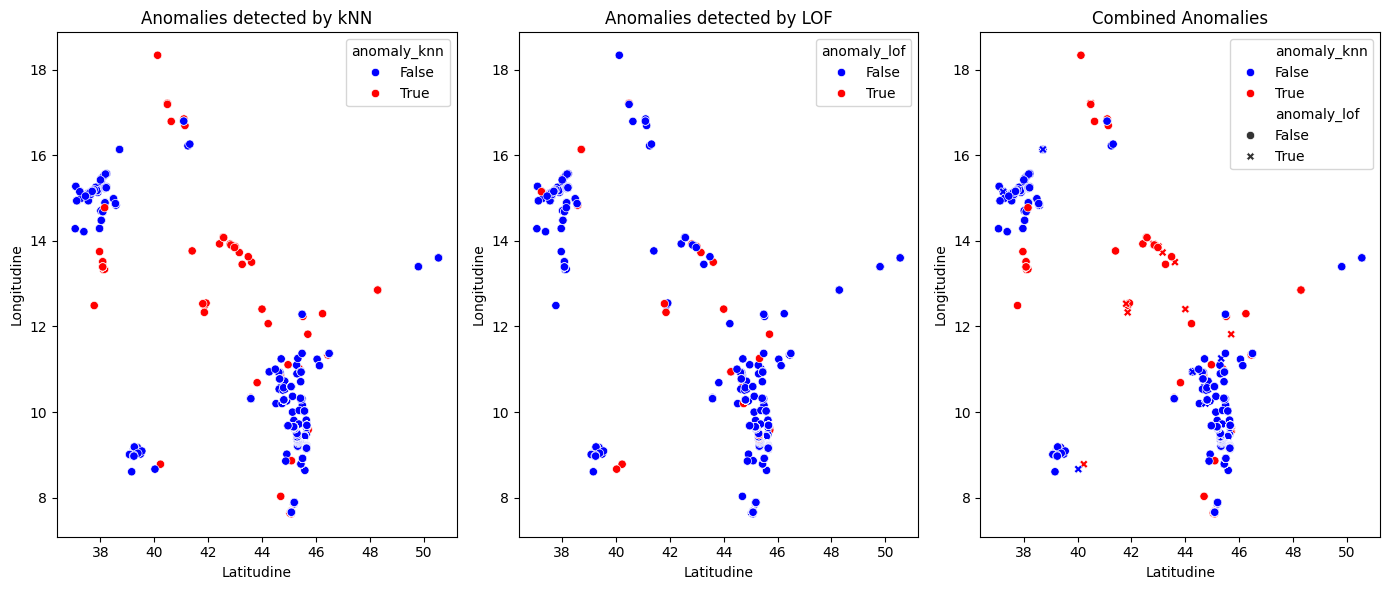

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from sklearn.preprocessing import StandardScaler
import folium

# Load the data
file_path = 'Anomalies_2021_2024.xlsx'
data = pd.read_excel(file_path)

# Preprocessing
# Convert 'latitudine' and 'longitudine' to numeric by replacing commas
data['latitudine'] = data['latitudine'].str.replace(',', '.').astype(float)
data['longitudine'] = data['longitudine'].str.replace(',', '.').astype(float)

# Fill missing values in 'idPunto' with a specific value or drop them based on the context
data['idPunto'] = data['idPunto'].fillna(-1)  # Using -1 to denote missing points

# Ensure 'note' is numeric and fill missing values with a placeholder (e.g., -1)
data['note'] = pd.to_numeric(data['note'], errors='coerce').fillna(-1)

# Select relevant features
features = data[['latitudine', 'longitudine', 'note', 'idPunto']].copy()

# Check for any remaining NaN values
print("Any NaN values in features:", features.isnull().values.any())

# Standardize the features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Detect anomalies using kNN
# Fit the model
k = 5  # Number of neighbors
nbrs = NearestNeighbors(n_neighbors=k)
nbrs.fit(features_scaled)

# Calculate the distance to the k-th nearest neighbor
distances, indices = nbrs.kneighbors(features_scaled)
k_distances = distances[:, -1]

# Set a threshold for anomaly detection
threshold = np.percentile(k_distances, 95)  # Top 5% distances
anomalies_knn = k_distances > threshold

# Detect anomalies using LOF
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
anomalies_lof = lof.fit_predict(features_scaled)
anomalies_lof = anomalies_lof == -1  # -1 indicates anomaly

# Create a dataframe to store results
results = data.copy()
results['anomaly_knn'] = anomalies_knn
results['anomaly_lof'] = anomalies_lof

# Filter rows where anomalies are detected
anomalies_detected = results[(results['anomaly_knn']) | (results['anomaly_lof'])]

# Plotting
plt.figure(figsize=(14, 6))

# Plot the original data points
plt.subplot(1, 3, 1)
sns.scatterplot(data=results, x='latitudine', y='longitudine', hue='anomaly_knn', palette={True: 'red', False: 'blue'})
plt.title('Anomalies detected by kNN')
plt.xlabel('Latitudine')
plt.ylabel('Longitudine')

# Plot anomalies detected by LOF
plt.subplot(1, 3, 2)
sns.scatterplot(data=results, x='latitudine', y='longitudine', hue='anomaly_lof', palette={True: 'red', False: 'blue'})
plt.title('Anomalies detected by LOF')
plt.xlabel('Latitudine')
plt.ylabel('Longitudine')

# Combined plot
plt.subplot(1, 3, 3)
sns.scatterplot(data=results, x='latitudine', y='longitudine', hue='anomaly_knn', style='anomaly_lof', palette={True: 'red', False: 'blue'}, markers={True: 'X', False: 'o'})
plt.title('Combined Anomalies')
plt.xlabel('Latitudine')
plt.ylabel('Longitudine')

plt.tight_layout()
plt.show()

# Create a Folium map to visualize clusters and anomalies
m = folium.Map(location=[data['latitudine'].mean(), data['longitudine'].mean()], zoom_start=10)

# Add points to the map
for _, row in results.iterrows():
    color = 'blue'  # Default color for normal points
    if row['anomaly_knn'] and row['anomaly_lof']:
        color = 'red'  # Anomalies detected by both methods
    elif row['anomaly_knn']:
        color = 'orange'  # Anomalies detected by kNN
    elif row['anomaly_lof']:
        color = 'purple'  # Anomalies detected by LOF

    folium.CircleMarker(
        location=[row['latitudine'], row['longitudine']],
        radius=5,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.7
    ).add_to(m)

# Save the map to an HTML file
m.save('anomalies_map.html')

# Display the map in the notebook (only for Google Colab)
m
